# K-Means Clustering of NYC Public School and MTA Subway Data

In [218]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

pd.set_option('display.max_columns', None)

In [219]:
subway_df = pd.read_csv('../cleaned_data/MTA_Subway_Grouped_Data.csv')

subway_df.head()

,line,num_stations,station_latitudes,station_longitudes,station_census_tracts,station_zip_codes,station_boroughs,stop_names,mta_performance_data
0,1,38,"[40.889248, 40.884667, 40.878856, 40.874561, 4...","[-73.898583, -73.90087, -73.904834, -73.909831...","[285, 283, 283, 309, 303, 293, 283, 277, 269, ...","[10463, 10463, 10463, 10468, 10034, 10034, 100...","['Bx', 'Bx', 'Bx', 'M', 'M', 'M', 'M', 'M', 'M...","['Van Cortlandt Park-242 St', '238 St', '231 S...","[['2015-01-01', 76.2337806, 1], ['2015-02-01',..."
1,2,49,"[40.793919, 40.778453, 40.75529, 40.750373, 40...","[-73.972323, -73.98197, -73.987495, -73.991057...","[183, 159, 113, 101, 71, 21, 21, 15, 7, 5, 11,...","[10025, 10023, 10018, 10119, 10011, 10007, 102...","['M', 'M', 'M', 'M', 'M', 'M', 'M', 'M', 'M', ...","['96 St', '72 St', 'Times Sq-42 St', '34 St-Pe...","[['2015-01-01', 47.2874494, 1], ['2015-02-01',..."
2,3,34,"[40.793919, 40.778453, 40.75529, 40.750373, 40...","[-73.972323, -73.98197, -73.987495, -73.991057...","[183, 159, 113, 101, 71, 21, 21, 15, 7, 5, 11,...","[10025, 10023, 10018, 10119, 10011, 10007, 102...","['M', 'M', 'M', 'M', 'M', 'M', 'M', 'M', 'M', ...","['96 St', '72 St', 'Times Sq-42 St', '34 St-Pe...","[['2015-01-01', 68.6321563, 1], ['2015-02-01',..."
3,4,28,"[40.688246, 40.684359, 40.670682, 40.668897, 4...","[-73.980492, -73.977666, -73.958131, -73.93294...","[37, 35, 213, 351, 431, 419, 409, 403, 401, 23...","[11217, 11217, 11238, 11213, 10467, 10467, 104...","['Bk', 'Bk', 'Bk', 'Bk', 'Bx', 'Bx', 'Bx', 'Bx...","['Nevins St', 'Atlantic Av-Barclays Ctr', 'Fra...","[['2015-01-01', 48.4323757, 1], ['2015-02-01',..."
4,5,45,"[40.688246, 40.684359, 40.670682, 40.667883, 4...","[-73.980492, -73.977666, -73.958131, -73.95068...","[37, 35, 213, 319, 329, 804, 820, 826, 830, 78...","[11217, 11217, 11238, 11225, 11225, 11225, 112...","['Bk', 'Bk', 'Bk', 'Bk', 'Bk', 'Bk', 'Bk', 'Bk...","['Nevins St', 'Atlantic Av-Barclays Ctr', 'Fra...","[['2015-01-01', 49.3452473, 1], ['2015-02-01',..."


In [220]:
schools_df = pd.read_csv('../cleaned_data/AllBoroughs_yearly_ratings.csv')
schools_df.head(10)

,School Building Number,QR Score,Assessment Time,Location Name,Primary Address,City,Zip,Census Tract,Community District,Latitude,Longitude
0,K544,6,2006-04-12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,K544,6,2007-04-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,K544,7,2008-03-15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,K544,6,2010-02-10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,K544,0,2014-12-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,K337,6,2006-04-26,International High School at Lafayette,2630 BENSON AVENUE,BROOKLYN,11214.0,30600.0,313.0,40.59928,-73.99644
6,K337,1,2007-05-23,International High School at Lafayette,2630 BENSON AVENUE,BROOKLYN,11214.0,30600.0,313.0,40.59928,-73.99644
7,K337,7,2008-05-15,International High School at Lafayette,2630 BENSON AVENUE,BROOKLYN,11214.0,30600.0,313.0,40.59928,-73.99644
8,K337,7,2009-05-02,International High School at Lafayette,2630 BENSON AVENUE,BROOKLYN,11214.0,30600.0,313.0,40.59928,-73.99644
9,K337,5,2012-03-28,International High School at Lafayette,2630 BENSON AVENUE,BROOKLYN,11214.0,30600.0,313.0,40.59928,-73.99644


# Data Preparation

In [221]:
schools_df['Census Tract'] = schools_df['Census Tract'].astype(float).astype('Int64').astype(str)
schools_df.head(10)

,School Building Number,QR Score,Assessment Time,Location Name,Primary Address,City,Zip,Census Tract,Community District,Latitude,Longitude
0,K544,6,2006-04-12,NaN,NaN,NaN,NaN,<NA>,NaN,NaN,NaN
1,K544,6,2007-04-28,NaN,NaN,NaN,NaN,<NA>,NaN,NaN,NaN
2,K544,7,2008-03-15,NaN,NaN,NaN,NaN,<NA>,NaN,NaN,NaN
3,K544,6,2010-02-10,NaN,NaN,NaN,NaN,<NA>,NaN,NaN,NaN
4,K544,0,2014-12-03,NaN,NaN,NaN,NaN,<NA>,NaN,NaN,NaN
5,K337,6,2006-04-26,International High School at Lafayette,2630 BENSON AVENUE,BROOKLYN,11214.0,30600,313.0,40.59928,-73.99644
6,K337,1,2007-05-23,International High School at Lafayette,2630 BENSON AVENUE,BROOKLYN,11214.0,30600,313.0,40.59928,-73.99644
7,K337,7,2008-05-15,International High School at Lafayette,2630 BENSON AVENUE,BROOKLYN,11214.0,30600,313.0,40.59928,-73.99644
8,K337,7,2009-05-02,International High School at Lafayette,2630 BENSON AVENUE,BROOKLYN,11214.0,30600,313.0,40.59928,-73.99644
9,K337,5,2012-03-28,International High School at Lafayette,2630 BENSON AVENUE,BROOKLYN,11214.0,30600,313.0,40.59928,-73.99644


# Goal:
- Use train performance as a predictor of school performance

# Troubleshooting:
- Census Tracts do not match up between subway stations and schools; use zip codes instead for mapping
- Zip codes didn't help much; using latitude and longitude data instead

In [222]:
schools_dim = schools_df[['School Building Number', 'Latitude', 'Longitude', 'Census Tract', 'Zip', 'Assessment Time', 'QR Score']].copy()

schools_dim = schools_dim[schools_dim['Census Tract'] != '<NA>']

schools_dim.head()

,School Building Number,Latitude,Longitude,Census Tract,Zip,Assessment Time,QR Score
5,K337,40.59928,-73.99644,30600,11214.0,2006-04-26,6
6,K337,40.59928,-73.99644,30600,11214.0,2007-05-23,1
7,K337,40.59928,-73.99644,30600,11214.0,2008-05-15,7
8,K337,40.59928,-73.99644,30600,11214.0,2009-05-02,7
9,K337,40.59928,-73.99644,30600,11214.0,2012-03-28,5


In [223]:
subway_df.head() # 26 rows

,line,num_stations,station_latitudes,station_longitudes,station_census_tracts,station_zip_codes,station_boroughs,stop_names,mta_performance_data
0,1,38,"[40.889248, 40.884667, 40.878856, 40.874561, 4...","[-73.898583, -73.90087, -73.904834, -73.909831...","[285, 283, 283, 309, 303, 293, 283, 277, 269, ...","[10463, 10463, 10463, 10468, 10034, 10034, 100...","['Bx', 'Bx', 'Bx', 'M', 'M', 'M', 'M', 'M', 'M...","['Van Cortlandt Park-242 St', '238 St', '231 S...","[['2015-01-01', 76.2337806, 1], ['2015-02-01',..."
1,2,49,"[40.793919, 40.778453, 40.75529, 40.750373, 40...","[-73.972323, -73.98197, -73.987495, -73.991057...","[183, 159, 113, 101, 71, 21, 21, 15, 7, 5, 11,...","[10025, 10023, 10018, 10119, 10011, 10007, 102...","['M', 'M', 'M', 'M', 'M', 'M', 'M', 'M', 'M', ...","['96 St', '72 St', 'Times Sq-42 St', '34 St-Pe...","[['2015-01-01', 47.2874494, 1], ['2015-02-01',..."
2,3,34,"[40.793919, 40.778453, 40.75529, 40.750373, 40...","[-73.972323, -73.98197, -73.987495, -73.991057...","[183, 159, 113, 101, 71, 21, 21, 15, 7, 5, 11,...","[10025, 10023, 10018, 10119, 10011, 10007, 102...","['M', 'M', 'M', 'M', 'M', 'M', 'M', 'M', 'M', ...","['96 St', '72 St', 'Times Sq-42 St', '34 St-Pe...","[['2015-01-01', 68.6321563, 1], ['2015-02-01',..."
3,4,28,"[40.688246, 40.684359, 40.670682, 40.668897, 4...","[-73.980492, -73.977666, -73.958131, -73.93294...","[37, 35, 213, 351, 431, 419, 409, 403, 401, 23...","[11217, 11217, 11238, 11213, 10467, 10467, 104...","['Bk', 'Bk', 'Bk', 'Bk', 'Bx', 'Bx', 'Bx', 'Bx...","['Nevins St', 'Atlantic Av-Barclays Ctr', 'Fra...","[['2015-01-01', 48.4323757, 1], ['2015-02-01',..."
4,5,45,"[40.688246, 40.684359, 40.670682, 40.667883, 4...","[-73.980492, -73.977666, -73.958131, -73.95068...","[37, 35, 213, 319, 329, 804, 820, 826, 830, 78...","[11217, 11217, 11238, 11225, 11225, 11225, 112...","['Bk', 'Bk', 'Bk', 'Bk', 'Bk', 'Bk', 'Bk', 'Bk...","['Nevins St', 'Atlantic Av-Barclays Ctr', 'Fra...","[['2015-01-01', 49.3452473, 1], ['2015-02-01',..."


In [224]:
schools_dim['Zip'] = schools_dim['Zip'].astype(float).astype('Int64').astype(str)
schools_dim.head()

,School Building Number,Latitude,Longitude,Census Tract,Zip,Assessment Time,QR Score
5,K337,40.59928,-73.99644,30600,11214,2006-04-26,6
6,K337,40.59928,-73.99644,30600,11214,2007-05-23,1
7,K337,40.59928,-73.99644,30600,11214,2008-05-15,7
8,K337,40.59928,-73.99644,30600,11214,2009-05-02,7
9,K337,40.59928,-73.99644,30600,11214,2012-03-28,5


In [225]:
# For creating a function to get the nearest subway station for each school based on latitude and longitude
from scipy.spatial import KDTree

# Build KDTree from all subway stations for efficient nearest neighbor search
all_stations_data = []
station_metadata = []  # To store station info and which line it belongs to

for index, row in subway_df.iterrows():
    station_line = row['line']
    station_lats = eval(row['station_latitudes']) if isinstance(row['station_latitudes'], str) else row['station_latitudes']
    station_lngs = eval(row['station_longitudes']) if isinstance(row['station_longitudes'], str) else row['station_longitudes']
    
    for indx, (lat, lng) in enumerate(zip(station_lats, station_lngs)):
        try:
            all_stations_data.append([lat, lng])
            station_metadata.append(station_line)
        except (ValueError, TypeError, IndexError):
            continue

# Create KDTree from all station coordinates
tree = KDTree(all_stations_data)

def get_nearest_subway_lines(school_lat, school_lng):
    '''
    * Input: 
        - school_lat (float) - The latitude of the school
        - school_lng (float) - The longitude of the school
    * Output: 
        - nearest_lines (list) - List of nearest subway lines within 1.2 miles
    '''
    nearest_lines = []
    
    # Handle NaN values and check for finite values
    try:
        school_lat = float(school_lat)
        school_lng = float(school_lng)
        # Check for NaN or infinity
        if not (np.isfinite(school_lat) and np.isfinite(school_lng)):
            return nearest_lines
    except (ValueError, TypeError):
        return nearest_lines
    
    # Query KDTree for all stations within ~0.017 degrees (roughly 1.2 miles)
    # Using radius search for efficiency
    radius = 0.017  # Approximate radius in degrees
    indices = tree.query_ball_point([school_lat, school_lng], radius)

    # Return unique subway lines for all nearby stations
    lines = [station_metadata[idx] for idx in indices if idx < len(station_metadata)]
    return list(set(lines))  # Remove duplicates


schools_dim['Nearest_Subway_Stations'] = schools_dim.apply(
    lambda row: get_nearest_subway_lines(row['Latitude'], row['Longitude']), 
    axis=1
)

schools_dim[1:10]

,School Building Number,Latitude,Longitude,Census Tract,Zip,Assessment Time,QR Score,Nearest_Subway_Stations
6,K337,40.59928,-73.99644,30600,11214,2007-05-23,1,"[N, D]"
7,K337,40.59928,-73.99644,30600,11214,2008-05-15,7,"[N, D]"
8,K337,40.59928,-73.99644,30600,11214,2009-05-02,7,"[N, D]"
9,K337,40.59928,-73.99644,30600,11214,2012-03-28,5,"[N, D]"
10,K337,40.59928,-73.99644,30600,11214,2013-12-06,6,"[N, D]"
11,K337,40.59928,-73.99644,30600,11214,2015-02-27,0,"[N, D]"
12,K337,40.59928,-73.99644,30600,11214,2017-10-21,0,"[N, D]"
13,K685,40.71428,-73.94602,52900,11211,2006-04-26,7,"[G, J, M, Z, L]"
14,K685,40.71428,-73.94602,52900,11211,2007-05-25,1,"[G, J, M, Z, L]"


In [226]:
subway_df.head()

,line,num_stations,station_latitudes,station_longitudes,station_census_tracts,station_zip_codes,station_boroughs,stop_names,mta_performance_data
0,1,38,"[40.889248, 40.884667, 40.878856, 40.874561, 4...","[-73.898583, -73.90087, -73.904834, -73.909831...","[285, 283, 283, 309, 303, 293, 283, 277, 269, ...","[10463, 10463, 10463, 10468, 10034, 10034, 100...","['Bx', 'Bx', 'Bx', 'M', 'M', 'M', 'M', 'M', 'M...","['Van Cortlandt Park-242 St', '238 St', '231 S...","[['2015-01-01', 76.2337806, 1], ['2015-02-01',..."
1,2,49,"[40.793919, 40.778453, 40.75529, 40.750373, 40...","[-73.972323, -73.98197, -73.987495, -73.991057...","[183, 159, 113, 101, 71, 21, 21, 15, 7, 5, 11,...","[10025, 10023, 10018, 10119, 10011, 10007, 102...","['M', 'M', 'M', 'M', 'M', 'M', 'M', 'M', 'M', ...","['96 St', '72 St', 'Times Sq-42 St', '34 St-Pe...","[['2015-01-01', 47.2874494, 1], ['2015-02-01',..."
2,3,34,"[40.793919, 40.778453, 40.75529, 40.750373, 40...","[-73.972323, -73.98197, -73.987495, -73.991057...","[183, 159, 113, 101, 71, 21, 21, 15, 7, 5, 11,...","[10025, 10023, 10018, 10119, 10011, 10007, 102...","['M', 'M', 'M', 'M', 'M', 'M', 'M', 'M', 'M', ...","['96 St', '72 St', 'Times Sq-42 St', '34 St-Pe...","[['2015-01-01', 68.6321563, 1], ['2015-02-01',..."
3,4,28,"[40.688246, 40.684359, 40.670682, 40.668897, 4...","[-73.980492, -73.977666, -73.958131, -73.93294...","[37, 35, 213, 351, 431, 419, 409, 403, 401, 23...","[11217, 11217, 11238, 11213, 10467, 10467, 104...","['Bk', 'Bk', 'Bk', 'Bk', 'Bx', 'Bx', 'Bx', 'Bx...","['Nevins St', 'Atlantic Av-Barclays Ctr', 'Fra...","[['2015-01-01', 48.4323757, 1], ['2015-02-01',..."
4,5,45,"[40.688246, 40.684359, 40.670682, 40.667883, 4...","[-73.980492, -73.977666, -73.958131, -73.95068...","[37, 35, 213, 319, 329, 804, 820, 826, 830, 78...","[11217, 11217, 11238, 11225, 11225, 11225, 112...","['Bk', 'Bk', 'Bk', 'Bk', 'Bk', 'Bk', 'Bk', 'Bk...","['Nevins St', 'Atlantic Av-Barclays Ctr', 'Fra...","[['2015-01-01', 49.3452473, 1], ['2015-02-01',..."


# Approach:
- Determine what lines affect which schools
- THEN, see what those lines' metrics are

- Standardize the encoded subway lines AND the dates

In [227]:
# One-Hot-Encoding of 'Nearest_Subway_Stations'
from sklearn.preprocessing import MultiLabelBinarizer
mlb = MultiLabelBinarizer()
subway_encoded = mlb.fit_transform(schools_dim['Nearest_Subway_Stations'])
subway_encoded_df = pd.DataFrame(subway_encoded, columns=mlb.classes_)
subway_encoded_df.head(10)

,1,2,3,4,5,6,7,A,B,C,D,E,F,FS,G,GS,J,L,M,N,Q,R,RS,SIR,W,Z
0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
7,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
8,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,1,1,0,0,0,0,0,0,1
9,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,1,1,0,0,0,0,0,0,1


In [228]:
subway_encoded_df.drop(columns=['SIR'], inplace=True)
subway_encoded_df.head(10)

,1,2,3,4,5,6,7,A,B,C,D,E,F,FS,G,GS,J,L,M,N,Q,R,RS,W,Z
0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0
7,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0
8,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,1,1,0,0,0,0,0,1
9,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,1,1,0,0,0,0,0,1


In [229]:
schools_w_mta = pd.concat([schools_dim.reset_index(drop=True), subway_encoded_df.reset_index(drop=True)], axis=1)
schools_w_mta.head()

,School Building Number,Latitude,Longitude,Census Tract,Zip,Assessment Time,QR Score,Nearest_Subway_Stations,1,2,3,4,5,6,7,A,B,C,D,E,F,FS,G,GS,J,L,M,N,Q,R,RS,W,Z
0,K337,40.59928,-73.99644,30600,11214,2006-04-26,6,"[N, D]",0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0
1,K337,40.59928,-73.99644,30600,11214,2007-05-23,1,"[N, D]",0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0
2,K337,40.59928,-73.99644,30600,11214,2008-05-15,7,"[N, D]",0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0
3,K337,40.59928,-73.99644,30600,11214,2009-05-02,7,"[N, D]",0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0
4,K337,40.59928,-73.99644,30600,11214,2012-03-28,5,"[N, D]",0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0


In [230]:
schools_w_mta['Assessment Time'] = pd.to_datetime(schools_w_mta['Assessment Time'], errors='coerce')
schools_w_mta.head()

,School Building Number,Latitude,Longitude,Census Tract,Zip,Assessment Time,QR Score,Nearest_Subway_Stations,1,2,3,4,5,6,7,A,B,C,D,E,F,FS,G,GS,J,L,M,N,Q,R,RS,W,Z
0,K337,40.59928,-73.99644,30600,11214,2006-04-26,6,"[N, D]",0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0
1,K337,40.59928,-73.99644,30600,11214,2007-05-23,1,"[N, D]",0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0
2,K337,40.59928,-73.99644,30600,11214,2008-05-15,7,"[N, D]",0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0
3,K337,40.59928,-73.99644,30600,11214,2009-05-02,7,"[N, D]",0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0
4,K337,40.59928,-73.99644,30600,11214,2012-03-28,5,"[N, D]",0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0


In [231]:
# Converting to UNIX timestamp
schools_w_mta['Assessment Time Epoch'] = schools_w_mta['Assessment Time'].apply(lambda x: x.timestamp() if pd.notnull(x) else np.nan)
schools_w_mta.head()

,School Building Number,Latitude,Longitude,Census Tract,Zip,Assessment Time,QR Score,Nearest_Subway_Stations,1,2,3,4,5,6,7,A,B,C,D,E,F,FS,G,GS,J,L,M,N,Q,R,RS,W,Z,Assessment Time Epoch
0,K337,40.59928,-73.99644,30600,11214,2006-04-26,6,"[N, D]",0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1.146010e+09
1,K337,40.59928,-73.99644,30600,11214,2007-05-23,1,"[N, D]",0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1.179878e+09
2,K337,40.59928,-73.99644,30600,11214,2008-05-15,7,"[N, D]",0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1.210810e+09
3,K337,40.59928,-73.99644,30600,11214,2009-05-02,7,"[N, D]",0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1.241222e+09
4,K337,40.59928,-73.99644,30600,11214,2012-03-28,5,"[N, D]",0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1.332893e+09


In [232]:
schools_w_mta['Assessment Time Epoch'][0]

1146009600.0

# Standardizing Data:

In [233]:
features = ['Assessment Time Epoch'] + list(subway_encoded_df.columns)
X = schools_w_mta[features].dropna()

scarler = StandardScaler()
X_scaled = scarler.fit_transform(X)


# Elbow Method:

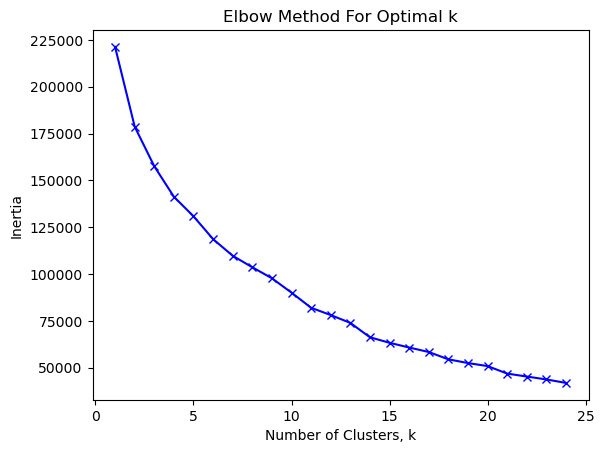

In [234]:
inertia = []
K_range = range(1, 25)

for k in K_range:
    model = KMeans(n_clusters=k, random_state=73, n_init=10)
    model.fit(X_scaled)
    inertia.append(model.inertia_)

plt.plot(K_range, inertia, 'bx-')
plt.xlabel('Number of Clusters, k')
plt.ylabel('Inertia')
plt.title('Elbow Method For Optimal k')
plt.savefig('../images/elbow_method_kmeans.png')
plt.show()

# Silhouette Score:

k=2, Silhouette Score=0.3876025918390797
k=3, Silhouette Score=0.23727120063030796
k=4, Silhouette Score=0.2528421060339424
k=5, Silhouette Score=0.2332387846812847
k=6, Silhouette Score=0.2711061938966218
k=7, Silhouette Score=0.29067298415277393
k=8, Silhouette Score=0.29870876852409284
k=9, Silhouette Score=0.28520122486977434
k=10, Silhouette Score=0.29723814028202966
k=11, Silhouette Score=0.2960846092081174
k=12, Silhouette Score=0.3270326580490099
k=13, Silhouette Score=0.2923434901994622
k=14, Silhouette Score=0.3417463568672592
k=15, Silhouette Score=0.3482125728477619
k=16, Silhouette Score=0.3594717420219538
k=17, Silhouette Score=0.3641065862275288
k=18, Silhouette Score=0.3884716886896751
k=19, Silhouette Score=0.3418205458115317
k=20, Silhouette Score=0.3895309786964291
k=21, Silhouette Score=0.41604694520372676
k=22, Silhouette Score=0.42225887436684406
k=23, Silhouette Score=0.42640760859289184
k=24, Silhouette Score=0.3860415746732206


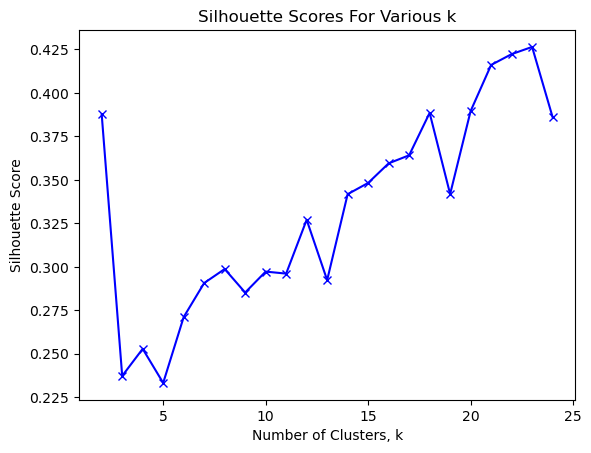

In [235]:
sil_scores = []
k_range = range(2, 25)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=73, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    sil_score = silhouette_score(X_scaled, labels)
    sil_scores.append(sil_score)
    print(f'k={k}, Silhouette Score={sil_score}')

plt.plot(k_range, sil_scores, 'bx-')
plt.xlabel('Number of Clusters, k')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores For Various k')
plt.savefig('../images/silhouette_scores_kmeans.png')
plt.show()

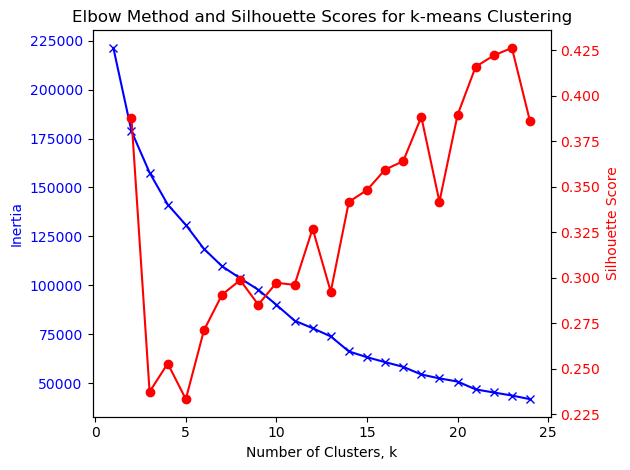

In [236]:
# Plotting both Elbow Method and Silhouette Scores together
fig, ax1 = plt.subplots()
ax1.plot(K_range, inertia, 'bx-', label='Inertia (Elbow Method)')
ax1.set_xlabel('Number of Clusters, k')
ax1.set_ylabel('Inertia', color='b')
ax1.tick_params(axis='y', labelcolor='b')
ax2 = ax1.twinx()
ax2.plot(k_range, sil_scores, 'ro-', label='Silhouette Score')
ax2.set_ylabel('Silhouette Score', color='r')
ax2.tick_params(axis='y', labelcolor='r')
plt.title('Elbow Method and Silhouette Scores for k-means Clustering')
fig.tight_layout()
plt.savefig('../images/elbow_silhouette_kmeans.png')
plt.show()

# Optimal k = 8

In [237]:
optimal_k = 8
model = KMeans(n_clusters=optimal_k, random_state=73, n_init=10)
X['cluster'] = model.fit_predict(X_scaled)

X.head(10)

,Assessment Time Epoch,1,2,3,4,5,6,7,A,B,C,D,E,F,FS,G,GS,J,L,M,N,Q,R,RS,W,Z,cluster
0,1.146010e+09,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1
1,1.179878e+09,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1
2,1.210810e+09,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1
3,1.241222e+09,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1
4,1.332893e+09,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1
5,1.386288e+09,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1
6,1.424995e+09,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1
7,1.508544e+09,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1
8,1.146010e+09,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,1,1,0,0,0,0,0,1,7
9,1.180051e+09,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,1,1,0,0,0,0,0,1,7


In [238]:
# Using PCA for X_scaled array (26 features) to 2 components for visualization

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
X_pca_df = pd.DataFrame(X_pca, columns=['PCA1', 'PCA2'])
X_pca_df['cluster'] = X['cluster']
X_pca_df.head()

,PCA1,PCA2,cluster
0,-1.136810,-0.299088,1
1,-1.134587,-0.298858,1
2,-1.132557,-0.298647,1
3,-1.130560,-0.298440,1
4,-1.124544,-0.297816,1


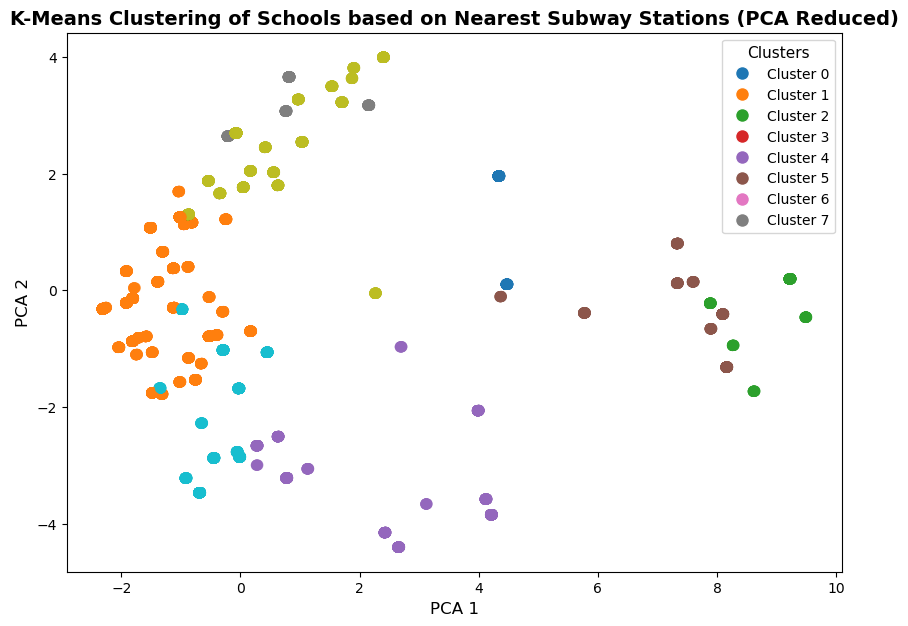

In [239]:
# Plotting X_pca_df

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca_df['PCA1'], X_pca_df['PCA2'], c=X_pca_df['cluster'], cmap='tab10', alpha=0.7, s=50)
plt.xlabel('PCA 1', fontsize=12)
plt.ylabel('PCA 2', fontsize=12)
plt.title('K-Means Clustering of Schools based on Nearest Subway Stations (PCA Reduced)', fontsize=14, fontweight='bold')

# Add legend
unique_clusters = sorted(X_pca_df['cluster'].unique())
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=plt.cm.tab10(i/10), markersize=10, label=f'Cluster {cluster}') 
           for i, cluster in enumerate(unique_clusters)]
plt.legend(handles=handles, loc='best', fontsize=10, title='Clusters', title_fontsize=11)

plt.savefig('../images/kmeans_clusters_pca.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Re-joining school building numbers and QR scores

clustered_df = pd.merge(X[['cluster']], schools_w_mta, left_index=True, right_index=True, how='inner')
clustered_df.head()

,cluster,School Building Number,Latitude,Longitude,Census Tract,Zip,Assessment Time,QR Score,Nearest_Subway_Stations,1,2,3,4,5,6,7,A,B,C,D,E,F,FS,G,GS,J,L,M,N,Q,R,RS,W,Z,Assessment Time Epoch
0,1,K337,40.59928,-73.99644,30600,11214,2006-04-26,6,"[N, D]",0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1.146010e+09
1,1,K337,40.59928,-73.99644,30600,11214,2007-05-23,1,"[N, D]",0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1.179878e+09
2,1,K337,40.59928,-73.99644,30600,11214,2008-05-15,7,"[N, D]",0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1.210810e+09
3,1,K337,40.59928,-73.99644,30600,11214,2009-05-02,7,"[N, D]",0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1.241222e+09
4,1,K337,40.59928,-73.99644,30600,11214,2012-03-28,5,"[N, D]",0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1.332893e+09


In [256]:
# Separating out the schools by cluster for further analysis

clustered_schools = {}
for cluster_num in range(optimal_k):
    clustered_schools[cluster_num] = clustered_df[clustered_df['cluster'] == cluster_num]

clustered_schools[3]

,cluster,School Building Number,Latitude,Longitude,Census Tract,Zip,Assessment Time,QR Score,Nearest_Subway_Stations,1,2,3,4,5,6,7,A,B,C,D,E,F,FS,G,GS,J,L,M,N,Q,R,RS,W,Z,Assessment Time Epoch
2647,3,M459,40.76472,-73.96332,11800,10065,2006-04-05,6,"[4, W, M, 6, F, 5, N, R, E, Q]",0,0,0,1,1,1,0,0,0,0,0,1,1,0,0,0,0,0,1,1,1,1,0,1,0,1.144195e+09
2648,3,M459,40.76472,-73.96332,11800,10065,2007-05-24,1,"[4, W, M, 6, F, 5, N, R, E, Q]",0,0,0,1,1,1,0,0,0,0,0,1,1,0,0,0,0,0,1,1,1,1,0,1,0,1.179965e+09
2649,3,M459,40.76472,-73.96332,11800,10065,2008-05-23,6,"[4, W, M, 6, F, 5, N, R, E, Q]",0,0,0,1,1,1,0,0,0,0,0,1,1,0,0,0,0,0,1,1,1,1,0,1,0,1.211501e+09
2650,3,M459,40.76472,-73.96332,11800,10065,2012-05-09,6,"[4, W, M, 6, F, 5, N, R, E, Q]",0,0,0,1,1,1,0,0,0,0,0,1,1,0,0,0,0,0,1,1,1,1,0,1,0,1.336522e+09
2651,3,M459,40.76472,-73.96332,11800,10065,2015-04-03,0,"[4, W, M, 6, F, 5, N, R, E, Q]",0,0,0,1,1,1,0,0,0,0,0,1,1,0,0,0,0,0,1,1,1,1,0,1,0,1.428019e+09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6073,3,Q236,40.73892,-73.87854,46100,11373,2015-05-06,0,"[M, 7, F, R, E]",0,0,0,0,0,0,1,0,0,0,0,1,1,0,0,0,0,0,1,0,0,1,0,0,0,1.430870e+09
6074,3,Q236,40.73892,-73.87854,46100,11373,2017-03-03,0,"[M, 7, F, R, E]",0,0,0,0,0,0,1,0,0,0,0,1,1,0,0,0,0,0,1,0,0,1,0,0,0,1.488499e+09
6085,3,Q361,40.74483,-73.90516,25700,11377,2016-05-12,0,"[M, F, 7, R, E]",0,0,0,0,0,0,1,0,0,0,0,1,1,0,0,0,0,0,1,0,0,1,0,0,0,1.463011e+09
6086,3,Q361,40.74483,-73.90516,25700,11377,2018-03-09,0,"[M, F, 7, R, E]",0,0,0,0,0,0,1,0,0,0,0,1,1,0,0,0,0,0,1,0,0,1,0,0,0,1.520554e+09


In [257]:
# Showing summary statistics for each cluster
for cluster_num in range(optimal_k):
    print(f"Cluster {cluster_num} Subway Line Count:")
    print(f"Total Schools in Cluster: {len(clustered_schools[cluster_num])}")
    for line in subway_encoded_df.columns:
        line_count = clustered_schools[cluster_num][line].sum()
        print(f"  {line}: {line_count}")
    print("\n")

Cluster 0 Subway Line Count:
Total Schools in Cluster: 234
  1: 0
  2: 234
  3: 234
  4: 234
  5: 234
  6: 0
  7: 0
  A: 162
  B: 234
  C: 234
  D: 234
  E: 0
  F: 162
  FS: 0
  G: 234
  GS: 0
  J: 72
  L: 0
  M: 72
  N: 234
  Q: 234
  R: 234
  RS: 0
  W: 0
  Z: 72


Cluster 1 Subway Line Count:
Total Schools in Cluster: 4142
  1: 251
  2: 625
  3: 0
  4: 222
  5: 861
  6: 656
  7: 194
  A: 372
  B: 181
  C: 49
  D: 360
  E: 0
  F: 392
  FS: 0
  G: 191
  GS: 0
  J: 0
  L: 204
  M: 120
  N: 421
  Q: 336
  R: 256
  RS: 37
  W: 21
  Z: 0


Cluster 2 Subway Line Count:
Total Schools in Cluster: 162
  1: 162
  2: 150
  3: 150
  4: 150
  5: 150
  6: 162
  7: 162
  A: 131
  B: 162
  C: 131
  D: 162
  E: 131
  F: 162
  FS: 0
  G: 0
  GS: 162
  J: 0
  L: 63
  M: 162
  N: 162
  Q: 162
  R: 162
  RS: 0
  W: 162
  Z: 0


Cluster 3 Subway Line Count:
Total Schools in Cluster: 637
  1: 0
  2: 0
  3: 0
  4: 113
  5: 113
  6: 266
  7: 287
  A: 0
  B: 145
  C: 0
  D: 145
  E: 366
  F: 571
  FS: 0
  G: 

In [242]:
schools_w_mta[['School Building Number', 'Assessment Time', 'QR Score']]

,School Building Number,Assessment Time,QR Score
0,K337,2006-04-26,6
1,K337,2007-05-23,1
2,K337,2008-05-15,7
3,K337,2009-05-02,7
4,K337,2012-03-28,5
...,...,...,...
8506,X595,2019-11-08,0
8507,X593,2019-12-20,0
8508,X596,2020-01-10,0
8509,X594,2020-01-16,0
